# Supervised one-step forecast neural network
We train a conditional regression model that learns $x_{t+1} = f_{\theta} (x_t)$. Key properties 
- supervised learning
- feed-forward neural operator
- deterministic mapping, as opposed to stochastic $p(x_{t+1} | x_t)$
- conditioned on the current state. $prediction = model (current \ state)$ 

In [4]:
from copy import deepcopy

import torch
from torch.utils.data import DataLoader

import xarray as xr

from tqdm.notebook import tqdm # sliders 

from neural_net import get_net # transformer
from constants import * # meteo constants 

import matplotlib.pyplot as plt

In [5]:
torch.manual_seed(42)

# Settings

In [6]:
device = torch.device("cuda:0") # using only the first GPU (there are 2on kaitain) 
dtype = torch.bfloat16

In [14]:
batch_size = 64 # this can be big if we run on gpu 
# it's the way in which we split the training dataset to reduce computational cost 

n_epochs = 1 # 20 complete passes through the dataset 

n_layers = 4 # this will be used when calling the net 

# Load data

('time', 'var_name', 'longitude', 'latitude')


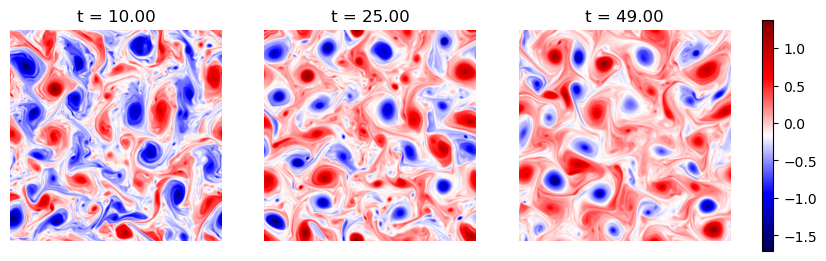

In [15]:
ds_train = xr.open_zarr("../data/sqg_train_small.zarr")["q"] # selecting q data from the dataset 
print(ds_train.dims)

# from model time to days 
def model_to_actual_time(t):
    return t  # <-- replace later with your real formula

n_times = ds_train.sizes["time"]
indices = [10, n_times // 2, n_times - 1]

fig, axes = plt.subplots(ncols=3, figsize=(10, 3))
for ax, idx in zip(axes, indices):
    frame = ds_train.isel(time=idx, var_name=0)
    im = ax.imshow(frame, cmap="seismic", origin="lower")
    actual_time = model_to_actual_time(float(ds_train.time[idx]))
    ax.set_title(f"t = {actual_time:.2f}")
    ax.axis("off")
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.03, pad=0.04)
plt.show()

Training data: 1979 - 2017

Validation data: 2018 & 2019

In [16]:
# workers: we use 16 parallel threads / processes 
ds_train = xr.open_zarr("../data/sqg_train.zarr")["q"].compute(num_workers=0)

# Normalize data
# torch.cat = concatenate the two tensors 
train_data = torch.cat((
    (torch.as_tensor(ds_train.values[:-1], dtype=dtype) - in_mean) / in_std,
    (torch.as_tensor(ds_train.values[1:] - ds_train.values[:-1], dtype=dtype) - res_mean) / res_std
), dim=1)  # [T-1, 2, H, W]

# we have concatenated normalized input data and normalized residuals 

del ds_train # remove from memory the initial data. Now everything is in train_data 

# this creates a pytorch data loader, which controls how data batches are fed to the model for training 
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
# why can we have suffle=True without breaking the physics? 

In [17]:
ds_val = xr.open_zarr("../data/sqg_val.zarr")["q"].compute(num_workers=0)
val_data = torch.cat((
    (torch.as_tensor(ds_val.values[:-1], dtype=dtype)-in_mean) / in_std,
    (torch.as_tensor(ds_val.values[1:]-ds_val.values[:-1], dtype=dtype)-res_mean) / res_std
), dim=1)
del ds_val

val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# Define neural network
We use a vision transformer

In [18]:
n_blocks = 4
n_features = 64
model = get_net(
    # Input: intermediate state (1) + initial conditions (1)
    n_input=1,
    n_output=1, n_blocks=n_blocks, n_features=n_features, mult=2,
    # Activation of pseudo time
    n_embedding=0, wave_length=0.1,
    device=device, dtype=dtype
)
optim = torch.optim.Adam(model.parameters(), lr=1E-3) # we use the Adam optimizer here too

In [19]:
pbar_epoch = tqdm(range(n_epochs)) 
mse_val = torch.inf # initial mse value = infinity
best_mse = torch.inf
best_model = None # we'll select the best model when the minimum of the loss is reached 
for _ in pbar_epoch:
    pbar_train = tqdm(iter(train_loader), total=len(train_loader), leave=True)
    # Training loop
    model = model.train()
    for batch in pbar_train:        
        batch = batch.to(device=device, dtype=dtype)

        data_in = batch[:, 0:1]      # [batch, 1, H, W] - just q[t]
        data_target = batch[:, 1:2]  # [batch, 1, H, W] - just residual
        optim.zero_grad()
        # forward pass 
        prediction = model(data_in)
        # loss: E ||f theta (xt) - xt+1 ||
        error = (prediction - data_target).pow(2)
        mse_train = (error).mean()
        # gradient descent 
        mse_train.backward()
        optim.step()
        pbar_train.set_postfix(mse_train=mse_train.item(), mse_val=mse_val)


    mse_val = 0 # why set to zero now? 
    samples_val = 0
    pbar_val = tqdm(enumerate(val_loader), total=len(val_loader), leave=False)
    # Validation loop
    model = model.eval()
    for k, batch in pbar_val:        
        batch = batch.to(device=device, dtype=dtype)
        data_in = batch[:, 0:1]     
        data_target = batch[:, 1:2]
        
        with torch.no_grad():
            prediction = model(data_in)
        error = (prediction - data_target).pow(2)
        curr_se = (weights_lat * error).mean(dim=(1, 2, 3)).sum().item()
        mse_val = mse_val * samples_val + curr_se
        samples_val = samples_val + len(batch)
        mse_val = mse_val / samples_val

    pbar_train.set_postfix(mse_train=mse_train.item(), mse_val=mse_val)
        
    # Check if new model is better
    if mse_val < 0.999 * best_mse:
        best_mse = mse_val
        best_model = deepcopy(model).cpu()
        

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

# Store best model

In [23]:
state_dict = model.cpu().state_dict()
torch.save(state_dict, "../data/best_reg_model.ckpt")